In [1]:
import numpy as np
import torch
from matplotlib import pyplot as plt
import scipy.io
import torcwa
from tqdm.notebook import tqdm
%load_ext line_profiler

def get_sine_eps(x,f,a,eps):
    """Generate sine grating permittivity profile.

    Args:
        x (torch.tensor): 1D tensor of x positions.
        f (float): Fill factor (duty cycle) of high-index material.
        a (float): Period of the grating.
        eps (float): Permittivity of high-index material.

    Returns:
        torch.tensor: 1D tensor of permittivity profile.
    """
    eps = (1-f)*eps + 0.5*f*eps*(1+torch.cos(2*np.pi*x/a))
    return eps.unsqueeze(1)   # make shape (nx,1) so add_layer accepts it

def binary_sine_eps(x,z,f,grating_period,a,eps1,eps2):
    """Generate binary sine grating permittivity profile.

    Args:
        x (torch.tensor): 2D tensor of x positions, meshgrid
        z (torch.tensor): 2D tensor of z positions, meshgrid
        f (float): Fill factor (duty cycle) of high-index material.
        grating_period (float): Period of the grating.
        a (float): Height of the grating.
        eps1 (float): Permittivity of low-index material.
        eps2 (float): Permittivity of high-index material.

    Returns:
        torch.tensor: 2D tensor of permittivity profile.
    """
    eps = torch.where(z>a*(1-f) + a*0.5*f*(1+torch.cos(2*np.pi*x/grating_period)), eps2, eps1)
    return eps


# Hardware
# If GPU support TF32 tensor core, the matmul operation is faster than FP32 but with less precision.
# If you need accurate operation, you have to disable the flag below.
torch.backends.cuda.matmul.allow_tf32 = False
sim_dtype = torch.complex64
geo_dtype = torch.float32
device = torch.device('cuda')

# Simulation environment
# light
inc_ang = 0.*(np.pi/180)    # radian
azi_ang = 0.*(np.pi/180)    # radian

# material
substrate_eps = 1.46**2
photoresist_eps = 1.62**2
film_eps = 2**2

# geometry
a = 4000 # Å
d = 10000 # Å
f = 0.62 #fill factor
grating_period = 4340 # Å
L = [grating_period, 1.]  # Å
torcwa.rcwa_geo.dtype = geo_dtype
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 101
torcwa.rcwa_geo.ny = 1
torcwa.rcwa_geo.grid()
z = torch.linspace(-d,1.5*d,501,device=device)

x_axis = torcwa.rcwa_geo.x.cpu()
y_axis = torcwa.rcwa_geo.y.cpu()
z_axis = z.cpu()

In [4]:
x, z = (grating_period/101)*(torch.arange(101)+0.5), (a/101)*(torch.arange(101)+0.5)
X, Z = torch.meshgrid(x, z, indexing='xy')
eps_profile = binary_sine_eps(X, Z, f, grating_period, a,1,photoresist_eps)

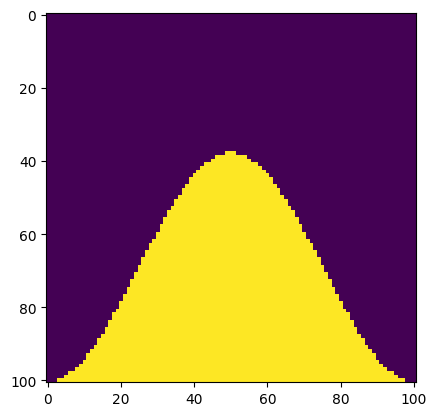

In [5]:
plt.imshow(eps_profile.cpu())

In [ ]:
# Generate and perform simulations
lamb0 = torch.tensor(6328.,dtype=geo_dtype,device=device)    # Å
sine_eps = get_sine_eps(torcwa.rcwa_geo.x, f, grating_period, photoresist_eps)
order_N = 50
order = [order_N,0]
E_fields = []
z_film = torch.linspace(a,d,50,device=device)
x_film = torch.linspace(0,grating_period,50,device=device)
angle_step = 0.05
angles = np.arange(4,32,angle_step)
for incidence in tqdm(angles):
    inc_ang = incidence*(np.pi/180)    # radian
    sim = torcwa.rcwa(freq=1/lamb0,order=order,L=L,dtype=sim_dtype,device=device)
    sim.add_input_layer()
    sim.add_output_layer(eps=substrate_eps)
    sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
    sim.add_layer(thickness=a,eps=sine_eps)
    sim.add_layer(thickness=d-a,eps=torch.tensor(film_eps))
    sim.solve_global_smatrix()
    sim.source_planewave(amplitude=[0.,1.],direction='forward',notation='xy')
    [Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_film,z_film,0)
    Enorm = torch.mean(torch.sqrt(torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2))
    E_fields.append(Enorm.cpu())  # store result to CPU memory

  0%|          | 0/560 [00:00<?, ?it/s]

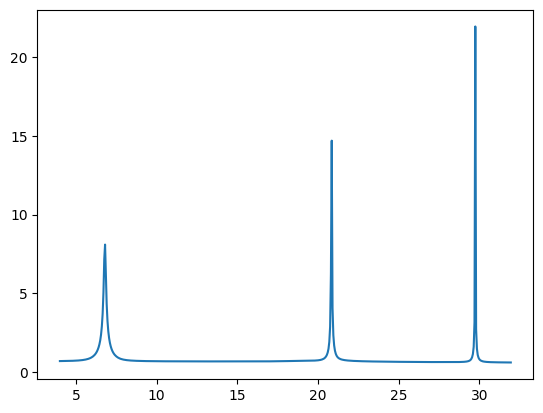

In [20]:
plt.plot(angles, E_fields)

In [12]:
#study of pure silicon - are peaks as sharp?
silicon_eps = (3.879 + 0.01644j)**2
E_fields_silicon = []

lamb0 = torch.tensor(6328.,dtype=geo_dtype,device=device)    # Å
sine_eps = get_sine_eps(torcwa.rcwa_geo.x, f, grating_period, silicon_eps)
order_N = 15
order = [order_N,0]
z_film = torch.linspace(a,d,50,device=device)
x_film = torch.linspace(0,grating_period,50,device=device)
angle_step = 1
angles = np.arange(0,40,angle_step)
for incidence in tqdm(angles):
    inc_ang = incidence*(np.pi/180)    # radian
    sim = torcwa.rcwa(freq=1/lamb0,order=order,L=L,dtype=sim_dtype,device=device)
    sim.add_input_layer()
    sim.add_output_layer()
    sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
    sim.add_layer(thickness=a,eps=sine_eps)
    sim.add_layer(thickness=d-a,eps=torch.tensor(silicon_eps))
    sim.solve_global_smatrix()
    sim.source_planewave(amplitude=[0.,1.],direction='forward',notation='xy')
    [Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_film,z_film,0)
    Enorm = torch.mean(torch.sqrt(torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2))
    E_fields_silicon.append(Enorm.cpu().numpy())  # store result to CPU memory

  0%|          | 0/40 [00:00<?, ?it/s]

Text(0, 0.5, 'Mean |E| in film layer (a.u.)')

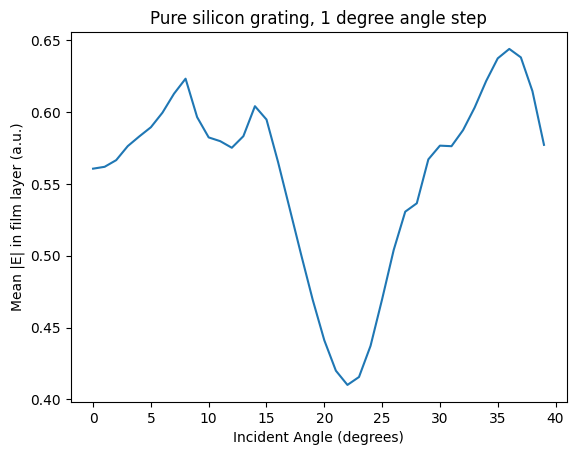

In [13]:
plt.plot(angles, E_fields_silicon)
plt.title('Pure silicon grating, 1 degree angle step')
plt.xlabel('Incident Angle (degrees)')
plt.ylabel('Mean |E| in film layer (a.u.)')

In [7]:
#study of pure silicon - are peaks as sharp?
silicon_eps = (3.879 + 0.01644j)**2
E_fields_silicon = []

lamb0 = torch.tensor(6328.,dtype=geo_dtype,device=device)    # Å
sine_eps = get_sine_eps(torcwa.rcwa_geo.x, f, grating_period, silicon_eps)
order_N = 15
order = [order_N,0]
z_film = torch.linspace(a,d,50,device=device)
x_film = torch.linspace(0,grating_period,50,device=device)
angle_step = 2
angles = np.arange(0,40,angle_step)
for incidence in tqdm(angles):
    inc_ang = incidence*(np.pi/180)    # radian
    sim = torcwa.rcwa(freq=1/lamb0,order=order,L=L,dtype=sim_dtype,device=device)
    sim.add_input_layer()
    sim.add_output_layer()
    sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
    sim.add_layer(thickness=a,eps=sine_eps)
    sim.add_layer(thickness=d-a,eps=torch.tensor(silicon_eps))
    sim.solve_global_smatrix()
    sim.source_planewave(amplitude=[0.,1.],direction='forward',notation='xy')
    [Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_film,z_film,0)
    Enorm = torch.mean(torch.sqrt(torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2))
    E_fields_silicon.append(Enorm.cpu().numpy())  # store result to CPU memory

  0%|          | 0/20 [00:00<?, ?it/s]

Text(0, 0.5, 'Mean |E| in film layer (a.u.)')

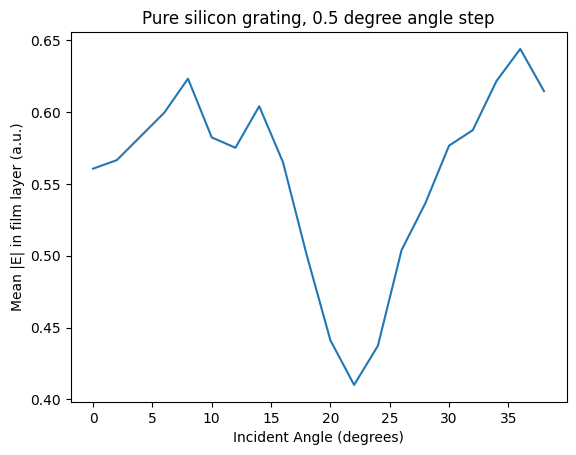

In [8]:
plt.plot(angles, E_fields_silicon)
plt.title('Pure silicon grating, 0.5 degree angle step')
plt.xlabel('Incident Angle (degrees)')
plt.ylabel('Mean |E| in film layer (a.u.)')

In [ ]:
#Study of pure silicon binary grating
silicon_eps = (3.879 + 0.01644j)**2
E_fields_silicon = []

lamb0 = torch.tensor(6328.,dtype=geo_dtype,device=device)    # Å
x, z = (grating_period/101)*(torch.arange(101)+0.5), (a/101)*(torch.arange(101)+0.5)
X, Z = torch.meshgrid(x, z, indexing='xy')
eps_profile = binary_sine_eps(X, Z, f, grating_period, a,1,photoresist_eps)
order_N = 50
order = [order_N,0]
E_fields = []
z_film = torch.linspace(a,d,50,device=device)
x_film = torch.linspace(0,grating_period,50,device=device)
angle_step = 2
angles = np.arange(0,40,angle_step)
for incidence in tqdm(angles):
    inc_ang = incidence*(np.pi/180)    # radian
    sim = torcwa.rcwa(freq=1/lamb0,order=order,L=L,dtype=sim_dtype,device=device)
    sim.add_input_layer()
    sim.add_output_layer(eps=substrate_eps)
    sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
    for i in range(eps_profile.shape[0]):
        sim.add_layer(thickness=a/eps_profile.shape[0],eps=eps_profile[i,:].unsqueeze(1).to(device))
    sim.add_layer(thickness=d-a,eps=torch.tensor(silicon_eps))
    sim.solve_global_smatrix()
    sim.source_planewave(amplitude=[0.,1.],direction='forward',notation='xy')
    [Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_film,z_film,0)
    Enorm = torch.mean(torch.sqrt(torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2))
    E_fields.append(Enorm.cpu())  # store result to CPU memory

  0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
plt.plot(angles, E_fields_silicon)
plt.title('Pure silicon grating, 0.5 degree angle step')
plt.xlabel('Incident Angle (degrees)')
plt.ylabel('Mean |E| in film layer (a.u.)')